## fpocket 200 clustering for ensemble docking (with 5 reps)

In [1]:
# kernel fpocket
import sys
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import MDAnalysis as mda
from MDAnalysis.analysis import align
from MDAnalysis.analysis.rms import rmsd, RMSF
from MDAnalysis import Universe

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, silhouette_score

/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


### Load data and select groups
Working with CTD domains of chain A and D.

In [10]:
base = "/biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein"
paths = {f"r{i}": os.path.join(base, f"Run{i}") for i in range(1, 6)}
working_dir = "/biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run1/clustering/allreps_site11"

universes = {}
for rep, path in paths.items():
    gro = os.path.join(path, "md_prot.gro")
    xtc = os.path.join(path, "md_prot_cent_ts100.xtc")
    universes[rep] = mda.Universe(gro, xtc)
    print(f"Loaded {rep}: {gro}, {xtc}")

# # store your replicate base paths
# paths = [
#     path_to_fullprot_r1,
#     path_to_fullprot_r2,
#     path_to_fullprot_r3,
#     path_to_fullprot_r4,
#     path_to_fullprot_r5
# ]

# universes = {}  # dict: rep_id -> Universe
# for i, path in enumerate(paths, start=1):
#     gro = os.path.join(path, "md_prot.gro")
#     xtc = os.path.join(path, "md_prot_cent_ts100.xtc")
#     u = mda.Universe(gro, xtc)
#     universes[f"r{i}"] = u
#     print(f"Loaded replicate {i}: {gro}, {xtc}")

# # Access like: universes["r1"], universes["r2"], ...

Loaded r1: /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run1/md_prot.gro, /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run1/md_prot_cent_ts100.xtc
Loaded r2: /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run2/md_prot.gro, /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run2/md_prot_cent_ts100.xtc
Loaded r3: /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run3/md_prot.gro, /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run3/md_prot_cent_ts100.xtc
Loaded r4: /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run4/md_prot.gro, /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run4/md_prot_cent_ts100.xtc
Loaded r5: /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run5/md_prot.gro, /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run5/md_prot_cent_ts100.xtc


In [12]:
# Selection definitions
sel_CTD_A     = 'protein and bynum 9054:11750'
sel_CTD_D     = 'protein and bynum 44304:47000'
sel_AD_CTD    = f'{sel_CTD_A} or {sel_CTD_D}'

sel_fp11_A    = '(protein and resid 688 686 684 690 694 761 726 759 753 and bynum 9054:11750)'
sel_fp11_D    = '(protein and resid 658 660 659 661 680 and bynum 44304:47000)'
sel_fp11_AD   = f'{sel_fp11_A} or {sel_fp11_D}'
sel_fp11_AD_heavy = f'{sel_fp11_AD} and not name H* and not backbone'

# Build dictionaries for each rep
CTD_A     = {}
CTD_D     = {}
AD_CTD    = {}
fp11_AD   = {}
fp11_AD_heavy = {}

for rep, u in universes.items():   # universes["r1"], universes["r2"], ...
    CTD_A[rep]        = u.select_atoms(sel_CTD_A)
    CTD_D[rep]        = u.select_atoms(sel_CTD_D)
    AD_CTD[rep]       = u.select_atoms(sel_AD_CTD)
    fp11_AD[rep]      = u.select_atoms(sel_fp11_AD)
    fp11_AD_heavy[rep]= u.select_atoms(sel_fp11_AD_heavy)

# Example usage:
# CTD_A["r3"].positions
# fp11_AD_heavy["r5"].center_of_mass()


In [ ]:
# Atom selection for interface and non-int resids, only need single run for ref structure
path_to_interface = os.path.join(base,"Run1/clustering/", "chainD_within5A.csv")
interface = pd.read_csv(path_to_interface, index_col=0)
interface.drop_duplicates(inplace=True, subset=['0'])
interface_resnum_str = ' '.join(str(r) for r in interface.iloc[:,0].values)

# Interface selections
sel_int_CTD_A = f'protein and resid {interface_resnum_str} and bynum 9054:11750'
sel_int_CTD_D = f'protein and resid {interface_resnum_str} and bynum 44304:47000'
sel_int_CTD_all = f'protein and resid {interface_resnum_str} and (bynum 44304:47000 or bynum 9054:11750)'
sel_not_int = f'({sel_AD_CTD}) and not ({sel_int_CTD_A} or {sel_int_CTD_D})'
sel_not_int_BB = f'{sel_not_int} and name CA C N O'




### Align domains - all residues not at interface
Align each rep to the all backbone resids that are not involved in the interface of the CTD domains from chains A and D.

In [14]:
# Load real structure PDB
# Note: ref must be a pdb not gro file - affects the output
# Frame to align to:
pdb_frame = os.path.join(working_dir, "6edw_fix.pdb") # full protein 
u_pdb = mda.Universe(pdb_frame)

# Select protein only
pdb_prot = u_pdb.select_atoms('protein')
ref = Universe(pdb_frame)


/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


In [ ]:
# Align trajectories per rep to pdb reference structure

for rep, u in universes.items():   # universes["r1"], universes["r2"], ...
    # Alignment object
    aligner = align.AlignTraj(
        u, ref,
        select=sel_not_int_BB,
        weights="mass",
        filename=f"rmsfit_{rep}.xtc",
        in_memory=True
    )
    aligner.run()

    # Save aligned trajectory
    xtc_out = f"{rep}_aligned.xtc"
    pdb_out = f"{rep}_aligned.pdb"

    with mda.Writer(xtc_out, n_atoms=u.atoms.n_atoms) as W:
        for ts in u.trajectory:
            W.write(u.atoms)

    u.atoms.write(pdb_out)
    print(f"Saved aligned files for {rep}: {xtc_out}, {pdb_out}")


Saved aligned files for r1: r1_aligned.xtc, r1_aligned.pdb
Saved aligned files for r2: r2_aligned.xtc, r2_aligned.pdb
Saved aligned files for r3: r3_aligned.xtc, r3_aligned.pdb
Saved aligned files for r4: r4_aligned.xtc, r4_aligned.pdb
Saved aligned files for r5: r5_aligned.xtc, r5_aligned.pdb


### Functions for calculating rmsd - compute per rep

In [23]:
def calc_rmsd(universe, reference, selection):
    """
    Calculate RMSD and plot graph
    """
    # Calculate RMSD
    rmsd = mda.analysis.rms.RMSD(universe, reference, selection, superposition= True)
    rmsd.run()

    # Extract results 
    frames = rmsd.results.rmsd[:,0]
    times = rmsd.results.rmsd[:,1]
    rmsd_out = rmsd.results.rmsd[:,2]

    # Plot graph
    plt.plot(times, rmsd_out)
    plt.xlabel("Time (ps)")
    plt.ylabel("Interface RMSD (Ang)")
    plt.grid(True)
    plt.show()

    return 

Calculating RMSD for rep r1 ...


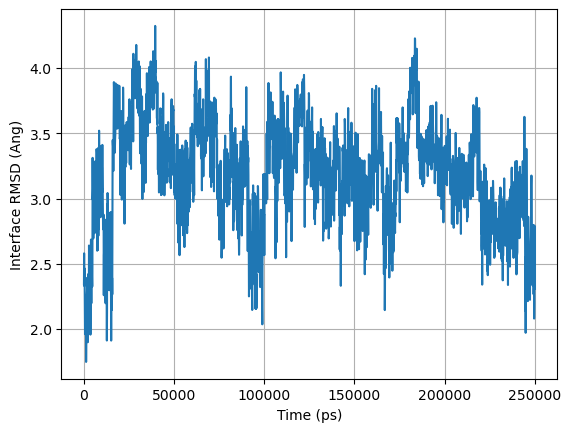

Calculating RMSD for rep r2 ...


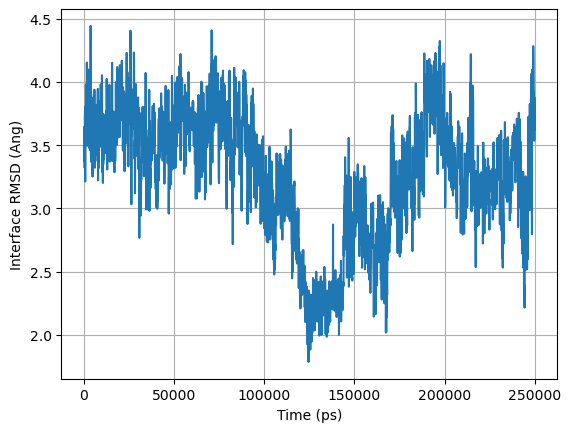

Calculating RMSD for rep r3 ...


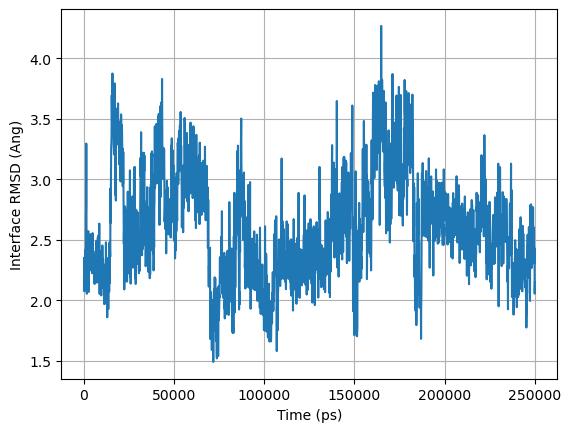

Calculating RMSD for rep r4 ...


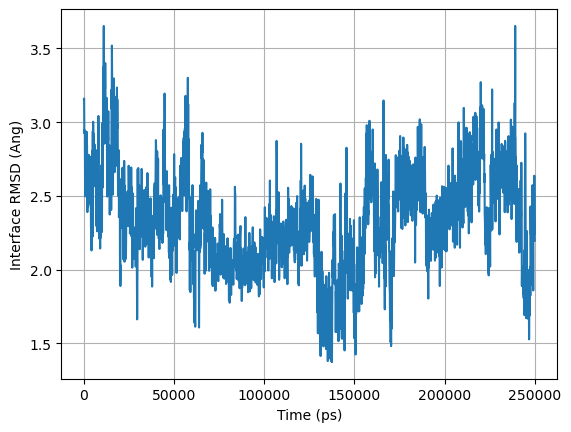

Calculating RMSD for rep r5 ...


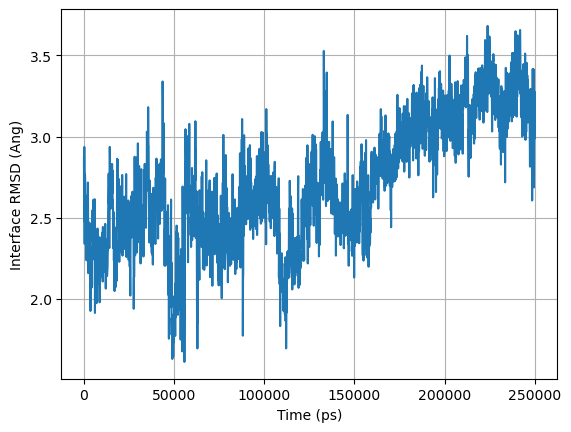

In [24]:
# RMSD 
for rep, u in universes.items():
    print(f'Calculating RMSD for rep {rep} ...')
    calc_rmsd(u, ref, f'{sel_fp11_AD_heavy}')

### Build coordinate vectors and concat reps 

In [25]:
# Build coordinate matrics and concat reps
# Select heavy atoms only 
sel_fp11_AD_heavy = f'{sel_fp11_AD} and not name H* and not backbone'

# Trajectories and universes
rep_trajs = [("./r1_aligned.pdb", "./r1_aligned.xtc"),
              ("./r2_aligned.pdb", "./r2_aligned.xtc"),
                ("./r3_aligned.pdb", "./r3_aligned.xtc"),
                ("./r4_aligned.pdb", "./r4_aligned.xtc"),
                ("./r5_aligned.pdb", "./r5_aligned.xtc")] # aligned trajectories

coords = []
frame_ids =[]
meta = []

for rep_id, (ref_pdb, ref_traj) in enumerate(rep_trajs):
    uni = Universe(ref_pdb, ref_traj)
    sel_atoms = uni.select_atoms(sel_fp11_AD_heavy)
    print(f'Analysing rep {rep_id+1}')

    for ts in uni.trajectory[1000:2500]:
        coords.append(sel_atoms.positions.flatten())
        frame_ids.append(uni.trajectory.frame)
        meta.append([rep_id, ts.time])

coords_all = np.vstack(coords)
print (f'Matrix formed and concatenated reps - matrix with shape {np.shape(coords_all)}')

/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


Analysing rep 1
Analysing rep 2
Analysing rep 3
Analysing rep 4
Analysing rep 5
Matrix formed and concatenated reps - matrix with shape (7500, 189)


### PCA of coodinates on all reps together

In [31]:
# Function to perform PCA 
def do_PCA(coords, n_PCA_components):
    """
    Perform PCA to reduce noise/ dimensionality

    Inputs:
        coords: Coordinates of matrix, after alignmnet and flattening 
        n_PCA_components: Specify number of PCA components
    
    """

    if coords.shape[0]<2:
        raise SystemExit ("Not enough frames for clustering")
    
    # Calculate PCA
    n_pcas = min(n_PCA_components, coords.shape[0], coords.shape[1])
    pca = PCA(n_components=n_pcas)
    Xpca = pca.fit_transform(coords)
    print ("PCA complete") 

    # Plot
    plt.scatter(Xpca[:,1], Xpca[:,2],marker='.')
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()

    return Xpca

PCA complete


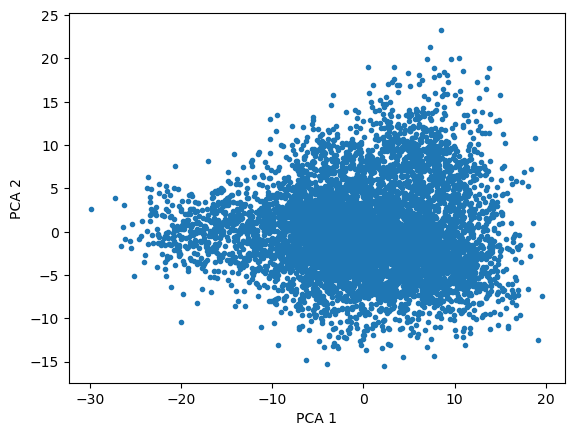

In [142]:
# Do PCA on all reps
Xpca_fp11 = do_PCA(coords_all, 10)

### Cluster (Kmeans) and medoid calculation 

In [46]:
# Clustering functions
# k_clusters=10 
path_to_cluster = os.path.join(working_dir)

def eval_KMeans(x, k_clusters, r):
    """
    Fit KMeans to data

    Inputs:
        x: Xpca data 
        k_clusters: number of clusters to form/ centroids
        r: random state
    """
    kmeans = KMeans(n_clusters=k_clusters, random_state=r)
    kmeans.fit(x)
    return kmeans.inertia_

# Use elbow method to pick suitable number of clusters
def elbow_KMeans(x, max_k, r=42):
    """Perform elbow method to obtain optimal number of clusters"""

    within_cluster_vars = [eval_KMeans(x,k,r) for k in range(1, max_k +1)]
    plt.plot(range(1,max_k+1), within_cluster_vars)
    plt.xlabel('K')
    plt.ylabel('Inertia')
    plt.show()

def scatter_kmeans(x, k_clusters, r):
    """Scatter plot the KMeans clusters
       Inputs:
        x: Xpca data
        k_clusters: number of clusters to cluster into
        r: random state
    """
    
    kmeans = KMeans(n_clusters=k_clusters, init='k-means++', random_state=r )
    y_pred = kmeans.fit_predict(x)

    # Plot
    # colours='rbgcmy'
    # colours = plt.cm.get_cmap('tab20', k_clusters)  # or 'tab10'
    cmap = plt.get_cmap('tab10' if k_clusters <= 10 else 'tab20', k_clusters)
    colours = cmap(np.arange(k_clusters))          # RGBA array of length k

    for c in range(k_clusters):
        plt.scatter(x[y_pred == c, 0], x[y_pred==c, 1], c=colours[c], label='Clusters{}'.format(c), marker='.')
        plt.scatter(kmeans.cluster_centers_[c,0], kmeans.cluster_centers_[c,1], marker='x', c='black')
        plt.xlabel('PC1')
        plt.ylabel('PC2')
    # score = round(silhouette_score(x, kmeans.labels_, metric='euclidean'), 2)
    plt.show()


    cluster_centroids={}
    medoid_rows=[]
    
    for me in range(k_clusters):
        indexes = np.where(y_pred == me)[0]
        centroid = x[indexes].mean(axis=0)
        cluster_centroids[c] = centroid 

        # medoid in PCA space
        dist = np.linalg.norm(x[indexes] - centroid, axis=1)
        medoid_row = indexes[np.argmin(dist)]
        medoid_rows.append(medoid_row)
    print (f'Medoid rows from concat reps matrix {medoid_rows}')

    # Write medoid structures from correct rep 
    for row in medoid_rows:
        rep_id, frame_id = meta[row]          # make sure frame_id is 0-based for that rep
        top, traj = rep_trajs[rep_id]
        u = mda.Universe(top, traj)
    
        try:
            u.trajectory[int(frame_id/100)]            # move to the medoid frame
        except IndexError:
            u.trajectory[int(frame_id/100)-1]          # if your meta uses 1-based indices

        # Save medoid frames
        output_name = f"medoid_cluster{y_pred[row]}_rep{rep_id}_frame{frame_id}.pdb"
        with mda.Writer(output_name) as W:    # safer writer context
            W.write(u.atoms)
        print("Wrote structure", output_name)


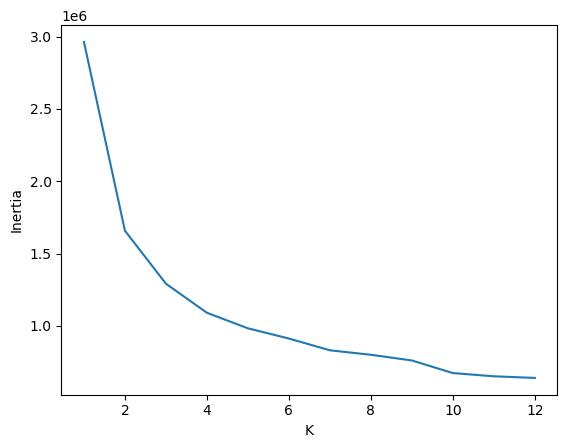

In [47]:
# Evaluate kmeans and plot elbow 
eval_KMeans(Xpca_fp11, 12, 42)
elbow_KMeans(Xpca_fp11,12)

/tmp/ipykernel_6391/3025692842.py:46: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x[y_pred == c, 0], x[y_pred==c, 1], c=colours[c], label='Clusters{}'.format(c), marker='.')


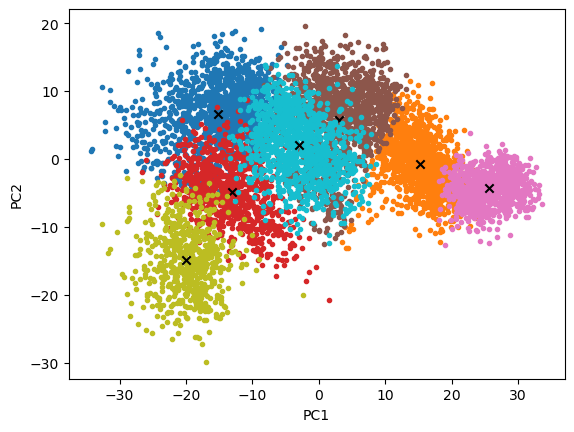

Medoid rows from concat reps matrix [2914, 5599, 349, 5337, 7466, 886, 3022]


/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'elements' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn("Found no information for attr: '{}'"


Wrote structure medoid_cluster0_rep1_frame241400.0.pdb
Wrote structure medoid_cluster1_rep3_frame209900.0.pdb
Wrote structure medoid_cluster2_rep0_frame134900.0.pdb
Wrote structure medoid_cluster3_rep3_frame183700.0.pdb
Wrote structure medoid_cluster4_rep4_frame246600.0.pdb
Wrote structure medoid_cluster5_rep0_frame188600.0.pdb
Wrote structure medoid_cluster6_rep2_frame102200.0.pdb


In [93]:
fp11_ypred = scatter_kmeans(Xpca_fp11, 7, 42)

DBSCAN found 9 clusters (+ noise)


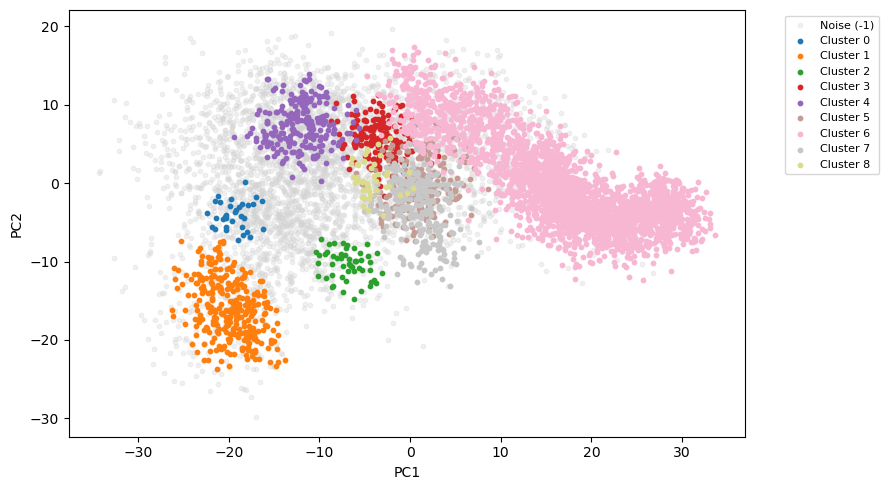

In [57]:
# Try DBSCAN

from sklearn.cluster import DBSCAN

# Xpca_fp11 is your PCA-transformed coordinates
X = Xpca_fp11[:, :10]   # example: first 10 PCs

# Run DBSCAN
# eps = neighborhood radius (tune this!)
# min_samples = how many neighbors to form a dense region
db = DBSCAN(eps=5.5, min_samples=30).fit(X)
labels = db.labels_   # -1 = noise, 0..N = cluster IDs

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"DBSCAN found {n_clusters} clusters (+ noise)")

# Plot in PC1 vs PC2 for visualization
plt.figure(figsize=(9,5))
unique_labels = set(labels)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))    

# plot noise first (underneath)
noise = labels == -1
if noise.any():
    plt.scatter(Xpca_fp11[noise, 0], Xpca_fp11[noise, 1],
                c='lightgrey', s=10, alpha=0.3, zorder=1, label='Noise (-1)')

# then plot the real clusters
for lbl, col in zip([l for l in unique_labels if l != -1], colors):
    mask = labels == lbl
    plt.scatter(Xpca_fp11[mask, 0], Xpca_fp11[mask, 1],
                c=[col], s=10, zorder=2, label=f'Cluster {lbl}')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


In [140]:
# Using HDBSCAN 

import hdbscan

def hdbscan_plot_pca(Xpca, n_pcs_for_cluster=10, min_cluster_size=200, min_samples=None):
    """
    Xpca: np.ndarray of shape (n_samples, n_pcs)  (PC scores; columns are PCs)
    n_pcs_for_cluster: how many PCs to use for clustering (use more than 2)
    min_cluster_size: ~ 0.5–2% of n_samples is a good start
    min_samples: None -> defaults to min_cluster_size; or set ~ 0.3–0.7 * min_cluster_size
    """
    X = np.asarray(Xpca)
    Xc = X[:, :n_pcs_for_cluster]

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric='euclidean',
        cluster_selection_method='eom', # standard
        prediction_data=True
    ).fit(Xc)

    labels = clusterer.labels_          # -1 = noise
    probs  = clusterer.probabilities_   # membership strength [0..1]

    # --- Plot PC1 vs PC2 ---
    fig, ax = plt.subplots(figsize=(8,5))

    # 1) plot noise UNDERNEATH (light grey, low alpha, low zorder)
    noise = labels == -1
    if noise.any():
        ax.scatter(X[noise, 0], X[noise, 1],
                   s=8, c='lightgrey', alpha=0.25, zorder=1, label='noise (-1)')

    # 2) plot clusters on top, coloured
    uniq = [l for l in np.unique(labels) if l != -1]
    cmap = plt.get_cmap('tab20', len(uniq) if len(uniq) > 0 else 1)

    medoid_indices = {}
    for i, lbl in enumerate(uniq):
        m = labels == lbl
        # Optional: weight alpha by membership probability so fuzzy points look lighter
        alpha_vals = 0.25 + 0.75*probs[m]   # map prob 0..1 -> 0.25..1.0

        ax.scatter(X[m, 0], X[m, 1],
                   s=10, color=cmap(i), alpha=None, zorder=2, label=f'C{lbl}')

        # mark a medoid-like representative (closest to cluster mean in the space we clustered in)
        cluster_pts = Xc[m]
        centroid = cluster_pts.mean(axis=0)
        local_idx = np.argmin(np.linalg.norm(cluster_pts - centroid, axis=1))
        global_idx = np.flatnonzero(m)[local_idx]
        medoid_indices[lbl] = global_idx
        ax.scatter(X[global_idx, 0], X[global_idx, 1],
                   marker='x', s=60, color='black', zorder=3)

    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
    plt.tight_layout()


    # --- Calculate and save medoid frames for each cluster ---
    medoid_indices = {}
    for i, lbl in enumerate(uniq):
        m = labels == lbl
        cluster_pts = Xc[m]
        centroid = cluster_pts.mean(axis=0)
        local_idx = np.argmin(np.linalg.norm(cluster_pts - centroid, axis=1))
        global_idx = np.flatnonzero(m)[local_idx]
        medoid_indices[lbl] = global_idx

    # Save medoid frames using meta and rep_trajs
    for lbl, row in medoid_indices.items():
        rep_id, frame_id = meta[row]  # meta[row] should be [rep_id, ts.time]
        top, traj = rep_trajs[rep_id]
        u = mda.Universe(top, traj)
        try:
            u.trajectory[int(frame_id/100)]  # adjust if needed for your frame indexing
        except IndexError:
            u.trajectory[int(frame_id/100)-1] # if metadata uses 1-based indices
        output_name = f"medoid_cluster{lbl}_rep{rep_id}_frame{frame_id}.pdb"
        with mda.Writer(output_name) as W:
            W.write(u.atoms)
        print(f"Wrote structure {output_name}")



/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'elements'

Wrote structure medoid_cluster0_rep1_frame235200.0.pdb
Wrote structure medoid_cluster1_rep0_frame134900.0.pdb
Wrote structure medoid_cluster2_rep0_frame197200.0.pdb
Wrote structure medoid_cluster3_rep1_frame140400.0.pdb
Wrote structure medoid_cluster4_rep2_frame136100.0.pdb
Wrote structure medoid_cluster5_rep3_frame100500.0.pdb
Wrote structure medoid_cluster6_rep4_frame140600.0.pdb


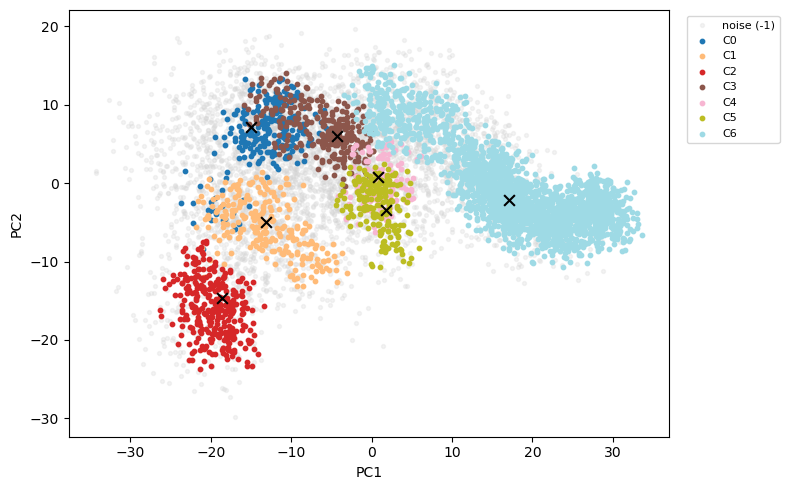

In [141]:
hdbscan_plot_pca(Xpca_fp11, n_pcs_for_cluster=10, min_cluster_size=40, min_samples=None)


In [139]:
# # Using HDBSCAN (soft + medoids + optional writing)
# import numpy as np
# import matplotlib.pyplot as plt
# import hdbscan
# from hdbscan import all_points_membership_vectors
# import MDAnalysis as mda  # only needed if write_medoids=True

# def hdbscan_plot_pca(
#     Xpca,
#     n_pcs_for_cluster=10,
#     min_cluster_size=40,
#     min_samples=None,
#     metric='euclidean',
#     cluster_selection_method='eom',
#     cluster_selection_epsilon=None,   # e.g. 0.5..1.0 in PCA units if you want a looser split
#     plot_pcs=(0, 1),                  # which PCs to plot: (PC1, PC2) -> (0,1); PC2 vs PC3 -> (1,2)
#     fade_by_prob=True,                # fade points by membership probability
#     min_prob_for_medoid=0.6,          # pick medoids from confident core members
#     cmap_name='tab20',
#     point_size=10,
#     noise_alpha=0.25,
#     write_medoids=False,              # writes PDBs if True and meta/rep_trajs provided
#     meta=None,                        # array-like [(rep_id, frame_idx), ...] aligned with rows of Xpca
#     rep_trajs=None,                   # dict/list: rep_id -> (top_path, traj_path)
#     out_prefix='medoid_hdb'
# ):
#     """
#     Returns:
#       labels, probs, medoid_indices, clusterer, M
#         labels: np.ndarray (n_samples,), -1 = noise
#         probs:  np.ndarray (n_samples,), HDBSCAN membership probabilities
#         medoid_indices: dict {cluster_label: row_index}
#         clusterer: fitted HDBSCAN object
#         M: np.ndarray (n_samples, n_clusters) soft membership matrix (weights per cluster)
#     """
#     X = np.asarray(Xpca)
#     assert X.ndim == 2, "Xpca must be (n_samples, n_pcs)"
#     pc_i, pc_j = plot_pcs
#     assert max(pc_i, pc_j) < X.shape[1], "plot_pcs indices exceed available PCs"

#     # ---- clustering space (PC1..PCk) ----
#     Xc = X[:, :min(n_pcs_for_cluster, X.shape[1])]

#     # ---- HDBSCAN ----
#     clusterer = hdbscan.HDBSCAN(
#         min_cluster_size=min_cluster_size,
#         min_samples=min_samples,
#         metric=metric,
#         cluster_selection_method=cluster_selection_method,
#         cluster_selection_epsilon=0,
#         prediction_data=True
#     ).fit(Xc)

#     labels = clusterer.labels_               # -1 = noise
#     probs  = clusterer.probabilities_        # confidence of assigned cluster (0..1)
#     M      = all_points_membership_vectors(clusterer)  # soft memberships to all clusters

#     # ---- plot PC_i vs PC_j ----
#     fig, ax = plt.subplots(figsize=(8, 5))

#     # noise first (underneath)
#     noise = (labels == -1)
#     if noise.any():
#         ax.scatter(X[noise, pc_i], X[noise, pc_j],
#                    s=point_size, c='lightgrey', alpha=noise_alpha, zorder=1, label='Noise (-1)')

#     # clusters
#     uniq = [l for l in np.unique(labels) if l != -1]
#     cmap = plt.get_cmap(cmap_name, max(len(uniq), 1))
#     medoid_indices = {}

#     for i, lbl in enumerate(uniq):
#         m = (labels == lbl)

#         if fade_by_prob:
#             # per-point RGBA with alpha scaled by membership probability
#             base = np.array(cmap(i))
#             cols = np.tile(base, (m.sum(), 1))
#             cols[:, 3] = 0.25 + 0.75 * probs[m]  # 0.25..1.0
#             ax.scatter(X[m, pc_i], X[m, pc_j], s=point_size, color=cols, zorder=2, label=f'C{lbl}')
#         else:
#             ax.scatter(X[m, pc_i], X[m, pc_j], s=point_size, color=cmap(i), zorder=2, label=f'C{lbl}')

#         # medoid-like representative (closest to mean in clustering space), from confident core points
#         m_core = m & (probs >= min_prob_for_medoid) if min_prob_for_medoid > 0 else m
#         if not np.any(m_core):
#             m_core = m  # fallback if prob filter removes all

#         cluster_pts = Xc[m_core]
#         centroid = cluster_pts.mean(axis=0)
#         d = np.linalg.norm(cluster_pts - centroid, axis=1)
#         local_idx = np.argmin(d)
#         global_idx = np.flatnonzero(m_core)[local_idx]
#         medoid_indices[lbl] = global_idx

#         # mark medoid on plot
#         ax.scatter(X[global_idx, pc_i], X[global_idx, pc_j],
#                    marker='x', s=60, color='black', zorder=3)

#     ax.set_xlabel(f'PC{pc_i+1}')
#     ax.set_ylabel(f'PC{pc_j+1}')
#     ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
#     plt.tight_layout()

#     # ---- optional: write medoid structures ----
#     if write_medoids:
#         if meta is None or rep_trajs is None:
#             raise ValueError("To write medoids, pass both `meta` and `rep_trajs`.")
#         for lbl, row in medoid_indices.items():
#             rep_id, frame_idx = meta[row]  # ensure this maps 1:1 to X rows
#             top, traj = rep_trajs[rep_id]
#             u = mda.Universe(top, traj)

#             # adjust if you subsampled frames upstream; here we assume frame_idx is the actual index
#             f = int(frame_idx)
#             if f < 0: f = 0
#             if f >= len(u.trajectory): f = len(u.trajectory) - 1
#             u.trajectory[f]

#             out = f"{out_prefix}_C{lbl}_rep{rep_id}_frame{f}.pdb"
#             with mda.Writer(out) as W:
#                 W.write(u.atoms)
#             print("Wrote", out)

#     # return labels, probs, medoid_indices, clusterer, M


### Check if medoid frames are significantly different from eachother
Just recalculate the RMSD between PDB and medoid of the heavy atoms in the pocket of interest <br>
Need to have run `fillin_allchains.sh`

In [125]:
# # pdb_frame = os.path.join(path_to_fullprot_r1, "6edw_fix.pdb") # full protein 
# # u_pdb = mda.Universe(pdb_frame)

# # Select atoms heavy atoms 
# pdb_fp11_heavy = u_pdb.select_atoms(sel_fp11_AD_heavy)

# # medoids
# medoid0_path = os.path.join(path_to_cluster, "medoid_cluster0_fp11.pdb")
# medoid0_pdb = mda.Universe(medoid0_path)
# medoid0_fp11_heavy = medoid0_pdb.select_atoms(sel_fp11_AD_heavy)

# medoid1_path = os.path.join(path_to_cluster, "medoid_cluster1_fp11.pdb")
# medoid1_pdb = mda.Universe(medoid1_path)

# medoid2_path = os.path.join(path_to_cluster, "medoid_cluster2_fp11.pdb")
# medoid2_pdb = mda.Universe(medoid2_path)

# medoid3_path = os.path.join(path_to_cluster, "medoid_cluster3_fp11.pdb")
# medoid3_pdb = mda.Universe(medoid3_path)

# medoid4_path = os.path.join(path_to_cluster, "medoid_cluster4_fp11.pdb")
# medoid4_pdb = mda.Universe(medoid4_path)

# medoid5_path = os.path.join(path_to_cluster, "medoid_cluster5_fp11.pdb")
# medoid5_pdb = mda.Universe(medoid5_path)

In [127]:
# # Calculate RMSD on the pocket 
# # calc_rmsd(medoid0_pdb, pdb_fp11_heavy, f'{sel_fp11_AD_heavy}')
# r = mda.analysis.rms.RMSD(medoid0_pdb, pdb_fp11_heavy, f'{sel_fp11_AD_heavy}', superposition=False, center=False)
# r.run()
# print (f"RMSD: {r}")
